# Data cleaning

In [1]:
# Methods to remove null values :
# 1.delete complete row with NAN
# 2.fill with dummy data
# 3.replace it with mean,median values

In [2]:
# Missing values
import numpy as np
import pandas as pd
sales_data=pd.DataFrame({'Name':['William','Emma','Sofia','Markus','Edward','Thomas','Ethan',np.nan,'Arun','Anika','Paulo'],
                        'Region':[np.nan,'North','East',np.nan,'West','West','South',np.nan,'West','East','South'],
                        'Sales':[50000,52000,np.nan,np.nan,42000,72000,49000,np.nan,67000,65000,67000],
                        'Expense':[42000,43000,np.nan,np.nan,38000,39000,42000,np.nan,39000,50000,45000]})
sales_data

,Name,Region,Sales,Expense
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
3,Markus,NaN,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
7,NaN,NaN,NaN,NaN
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0


# 1.delete complete row with NAN

In [3]:
sales_data.isna().sum()  # or sales_data.isnull().sum()

Name       1
Region     3
Sales      3
Expense    3
dtype: int64

In [4]:
sales_data.dropna()  

,Name,Region,Sales,Expense
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [5]:
sales_data.dropna(thresh=2)  # thresh=2 : 2 data must be valid

,Name,Region,Sales,Expense
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [6]:
sales_data.dropna(how='any')  # as simple dropna() and its by default

,Name,Region,Sales,Expense
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [7]:
sales_data.dropna(how='all')  # 'all'=all values are NAN than remove it

,Name,Region,Sales,Expense
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,NaN,NaN
3,Markus,NaN,NaN,NaN
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [8]:
sales_data.dropna(subset=['Sales','Expense'])  # perticular column's null values check

,Name,Region,Sales,Expense
0,William,NaN,50000.0,42000.0
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [9]:
sales_data.dropna(axis=0)  # axis=0 : row wise check that is default

,Name,Region,Sales,Expense
1,Emma,North,52000.0,43000.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0
10,Paulo,South,67000.0,45000.0


In [10]:
sales_data.dropna(axis=1)  # axis=1 : column wise check 

""
0
1
2
3
4
5
6
7
8
9


 # 2.fill with dummy data

In [11]:
sales_data.fillna(0)

,Name,Region,Sales,Expense
0,William,0,50000.0,42000.0
1,Emma,North,52000.0,43000.0
2,Sofia,East,0.0,0.0
3,Markus,0,0.0,0.0
4,Edward,West,42000.0,38000.0
5,Thomas,West,72000.0,39000.0
6,Ethan,South,49000.0,42000.0
7,0,0,0.0,0.0
8,Arun,West,67000.0,39000.0
9,Anika,East,65000.0,50000.0


In [12]:
sales_data['Name'].fillna("Guest")

0     William
1        Emma
2       Sofia
3      Markus
4      Edward
5      Thomas
6       Ethan
7       Guest
8        Arun
9       Anika
10      Paulo
Name: Name, dtype: object

# 3.replace it with mean,median values

In [13]:
sales_data['Sales'].fillna(sales_data['Sales'].mean())   # also use median()

0     50000.0
1     52000.0
2     58000.0
3     58000.0
4     42000.0
5     72000.0
6     49000.0
7     58000.0
8     67000.0
9     65000.0
10    67000.0
Name: Sales, dtype: float64

# auto-mpg csv 

In [14]:
df=pd.read_csv('auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [15]:
df=df[df['horsepower']!='?']
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [17]:
df['horsepower']=df['horsepower'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


<ipython-input-17-bc9932c3ca66>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['horsepower']=df['horsepower'].astype('int64')


In [18]:
df.drop('car name',axis=1)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


# Outliers

IQR=Interquartile Range
IQR=Q3-Q1
   where, Q3=75% , q1=25%
lower_val=Q1-(1.5*IQR)
higher_val=Q3+(1.5*IQR)

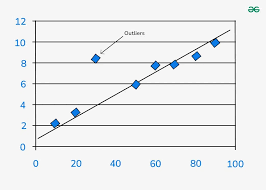

In [19]:
def find_outliers(ds,col):     #ds=dataset
    q1=ds[col].quantile(0.25)  # needs 25% value
    q3=ds[col].quantile(0.75)
    IQR=q3-q1
    lower_val=q1-(1.5*IQR)
    higher_val=q3+(1.5*IQR)
    print("Low:",lower_val,"High:",higher_val)
    ds=ds.loc[(ds[col]<lower_val)|(ds[col]>higher_val)]
    return ds
df=pd.read_csv('auto-mpg.csv')
find_outliers(df,'acceleration')

Low: 8.800000000000008 High: 22.199999999999992


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl
11,14.0,8,340.0,160,3609,8.0,70,1,plymouth 'cuda 340
59,23.0,4,97.0,54,2254,23.5,72,2,volkswagen type 3
195,29.0,4,85.0,52,2035,22.2,76,1,chevrolet chevette
299,27.2,4,141.0,71,3190,24.8,79,2,peugeot 504
300,23.9,8,260.0,90,3420,22.2,79,1,oldsmobile cutlass salon brougham
326,43.4,4,90.0,48,2335,23.7,80,2,vw dasher (diesel)
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup


In [20]:
# data that under outliers
def remove_outliers(ds,col):     #ds=dataset
    q1=ds[col].quantile(0.25)  # needs 25% value
    q3=ds[col].quantile(0.75)
    IQR=q3-q1
    lower_val=q1-(1.5*IQR)
    higher_val=q3+(1.5*IQR)
    print("Low:",lower_val,"High:",higher_val)
    ds=ds.loc[(ds[col]>lower_val)&(ds[col]<higher_val)] # only change here
    return ds
df=pd.read_csv('auto-mpg.csv')
remove_outliers(df,'acceleration')

Low: 8.800000000000008 High: 22.199999999999992


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


# Drop & Remove duplicate 

In [21]:
import pandas as pd
data={'A':['TeamA','TeamB','TeamB','TeamC','TeamA',],
     'B':[50,40,40,30,50],
     'C':[True,False,False,False,True]}
df=pd.DataFrame(data)
df

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
2,TeamB,40,False
3,TeamC,30,False
4,TeamA,50,True


In [22]:
df.duplicated()

0    False
1    False
2     True
3    False
4     True
dtype: bool

In [23]:
df.duplicated(keep='first') # uper thi jose

0    False
1    False
2     True
3    False
4     True
dtype: bool

In [24]:
df.duplicated(keep='last') # niche thi jose

0     True
1     True
2    False
3    False
4    False
dtype: bool

In [25]:
df.duplicated(keep=False) # duplicate=true 

0     True
1     True
2     True
3    False
4     True
dtype: bool

In [26]:
df.drop_duplicates()

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
3,TeamC,30,False


In [27]:
df.drop_duplicates(keep='first')

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
3,TeamC,30,False


In [28]:
df.drop_duplicates(keep='last')

,A,B,C
2,TeamB,40,False
3,TeamC,30,False
4,TeamA,50,True


In [29]:
df.drop_duplicates(keep=False)

,A,B,C
3,TeamC,30,False


In [30]:
df.drop_duplicates(inplace=True)
df

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
3,TeamC,30,False


In [31]:
df=df.reset_index(drop=True) 
df

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
2,TeamC,30,False


In [32]:
df.reset_index(drop=False) #drop=Fasle to show prevoise index

,index,A,B,C
0,0,TeamA,50,True
1,1,TeamB,40,False
2,2,TeamC,30,False
